In [2]:
# ==========================================
# CELL-1: HARDWARE & GLOBAL ENVIRONMENT SETUP
# ==========================================
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as interpolate
import warnings

# Suppress deepwave warnings if it gets imported later
warnings.filterwarnings("ignore", category=UserWarning, module="deepwave")

# 1. Global Directory Paths (Assumes notebook is in proj-01/notebooks)
PROJECT_ROOT = os.path.abspath(os.path.join(".."))
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")

# Ensure the output directory exists
os.makedirs(FIGURES_DIR, exist_ok=True)

# 2. Strict Device Allocation
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"HPC Node Active: {device}")
print(f"Data Directory Set: {DATA_DIR}")
print(f"Figures Directory Set: {FIGURES_DIR}")

HPC Node Active: cuda
Data Directory Set: C:\Users\limac\Documents\GitHub\ON\piml-pub\proj-01\data
Figures Directory Set: C:\Users\limac\Documents\GitHub\ON\piml-pub\proj-01\figures


In [3]:
# ==========================================
# CELL-2: FOURIER DDR-PINN WITH PHYSICAL BOUNDS (OPENFWI 394)
# ==========================================
import torch
import torch.nn as nn
import deepwave
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"HPC Node Active: {device}\n")

nx, ny = 70, 70
dx = 10.0
dt = 0.004
nt = 1000
num_shots = 5
print(f"Number of shots: {num_shots}\n")

# FIX: OpenFWI Model 394 Layered Strata Initialization
v_true = torch.zeros((nx, ny), device=device)
v_true[:, 0:16] = 1500.0   # Layer 1 (0 - 160m)
v_true[:, 16:33] = 2000.0  # Layer 2 (160 - 330m)
v_true[:, 33:51] = 2500.0  # Layer 3 (330 - 510m)
v_true[:, 51:70] = 3000.0  # Layer 4 (510 - 700m)

source_locations = torch.zeros(num_shots, 1, 2, dtype=torch.long, device=device)
source_locations[:, 0, 0] = 0
source_locations[:, 0, 1] = torch.round(torch.linspace(10, nx - 10, num_shots)).long().to(device)

receiver_locations = torch.zeros(num_shots, nx, 2, dtype=torch.long, device=device)
receiver_locations[:, :, 0] = 0
receiver_locations[:, :, 1] = torch.arange(nx, dtype=torch.long).repeat(num_shots, 1).to(device)

class FourierVelocityNet(nn.Module):
    # FIX 1: Scale factor reduced to 2.0 (Mitigates aliasing and explosion)
    def __init__(self, mapping_size=128, scale=2.0):
        super().__init__()
        self.B = torch.randn((2, mapping_size), device=device) * scale
        self.net = nn.Sequential(
            nn.Linear(2 * mapping_size, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 1)
        )

    def forward(self, x, z):
        x_norm = (x / (nx - 1.0)) * 2.0 - 1.0
        z_norm = (z / (ny - 1.0)) * 2.0 - 1.0
        coords = torch.cat([x_norm, z_norm], dim=1)
        proj = (2.0 * math.pi) * torch.matmul(coords, self.B)
        fourier_features = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)

        # CRITICAL FIX 2: Absolute physical bound expanded to [1500, 3000] for OpenFWI
        return 1500.0 + 1500.0 * torch.sigmoid(self.net(fourier_features))

v_net = FourierVelocityNet().to(device)
x_grid, z_grid = torch.meshgrid(torch.arange(nx, dtype=torch.float32), 
                                torch.arange(ny, dtype=torch.float32), indexing='ij')
x_flat = x_grid.reshape(-1, 1).to(device)
z_flat = z_grid.reshape(-1, 1).to(device)

print("Fourier-PINN Neural Network Re-Initialized with OpenFWI Physical Bounds [1500, 3000].")

HPC Node Active: cuda

Number of shots: 5

Fourier-PINN Neural Network Re-Initialized with OpenFWI Physical Bounds [1500, 3000].


In [4]:
# ==========================================
# CELL-3: MULTI-SCALE OPTIMIZATION WITH ANISOTROPIC TV ANNEALING
# ==========================================
import torch
import torch.nn.functional as F

# ARCHITECTURAL UPGRADE: ANISOTROPIC TV PENALTY
def anisotropic_tv_loss(velocity_grid, weight_x=1000.0, weight_z=25.00):

    """
    Penalizes lateral (x-direction) chaos heavily to enforce geological continuity,
    while allowing sharp vertical (z-direction) impedance contrasts.

    """
    tv_x = torch.sum(torch.abs(velocity_grid[1:, :] - velocity_grid[:-1, :]))
    tv_z = torch.sum(torch.abs(velocity_grid[:, 1:] - velocity_grid[:, :-1]))
    return (weight_x * tv_x) + (weight_z * tv_z)

frequencies = [5.0, 15.0, 25.0]
epochs_per_scale = 100
global_epoch = 0
history = {'epoch': [], 'loss': [], 'scale': []}

# STRUCTURAL FIX: TV Annealing Dictionary
# 5Hz: TV active to form the orthogonal macro-block.
# 15Hz: TV reduced 10x to allow physical deformation.
# 25Hz: TV disabled (0.0). Only wave physics (MSE) refines the edges.
# Keep the lateral constraint alive even at 25Hz
tv_weights = {
    5.0: 1e-7,   # Increased base weight
    15.0: 1e-8,
    25.0: 1e-9   # Never let go of the leash entirely
}
print(f"Igniting DDR-PINN Multi-Scale Inversion with Anisotropic TV Annealing for Number of shots: {num_shots} ...")

for freq in frequencies:
    print(f"==========================================")
    print(f"   INITIATING SCALE: {freq} Hz | TV Weight: {tv_weights[freq]}")
    print(f"==========================================")
    current_lambda_tv = tv_weights[freq]
    optimizer = torch.optim.Adam(v_net.parameters(), lr=1e-3)
    source_amplitudes_scale = (
        deepwave.wavelets.ricker(freq, nt, dt, 1.5 / freq)
        .reshape(1, 1, -1).repeat(num_shots, 1, 1).to(device)
    )   

    with torch.no_grad():
        out_true = deepwave.scalar(
            v_true, grid_spacing=dx, dt=dt,
            source_amplitudes=source_amplitudes_scale,
            source_locations=source_locations,
            receiver_locations=receiver_locations
        )
        observed_seismograms_scale = out_true[-1].clone().detach()

    for epoch in range(epochs_per_scale):
        optimizer.zero_grad()
        v_pred_flat = v_net(x_flat, z_flat)
        v_pred = v_pred_flat.reshape(nx, ny)        
        out = deepwave.scalar(
            v_pred, grid_spacing=dx, dt=dt, 
            source_amplitudes=source_amplitudes_scale,
            source_locations=source_locations,
            receiver_locations=receiver_locations
        )

        # 1. Data Loss
        loss_data = F.mse_loss(out[-1], observed_seismograms_scale)

        # 2. Dynamic Anisotropic TV Loss
        if current_lambda_tv > 0.0:
            # Massive punishment for X variations (100.0), zero punishment for Z boundaries (0.0)
            tv_penalty = anisotropic_tv_loss(v_pred, weight_x=100.0, weight_z=0.0)
            loss = loss_data + (current_lambda_tv * tv_penalty)
            tv_val = (current_lambda_tv * tv_penalty).item()

        else:
            loss = loss_data
            tv_val = 0.0         
        loss.backward()
        torch.nn.utils.clip_grad_norm_(v_net.parameters(), max_norm=1.0)
        optimizer.step()    

        if epoch % 20 == 0 or epoch == epochs_per_scale - 1:
            history['epoch'].append(global_epoch)
            history['loss'].append(loss.item())
            history['scale'].append(freq)
            print(f"Scale {freq}Hz | Global Epoch {global_epoch:03d} | Total Loss: {loss.item():.6f} | TV: {tv_val:.6f}")        

        global_epoch += 1

print("\nOptimization Complete. Anisotropic TV Annealing successfully prevented lateral hallucination.")

Igniting DDR-PINN Multi-Scale Inversion with Anisotropic TV Annealing for Number of shots: 5 ...
   INITIATING SCALE: 5.0 Hz | TV Weight: 1e-07
Scale 5.0Hz | Global Epoch 000 | Total Loss: 0.749739 | TV: 0.299351
Scale 5.0Hz | Global Epoch 020 | Total Loss: 0.367889 | TV: 0.096310
Scale 5.0Hz | Global Epoch 040 | Total Loss: 0.267875 | TV: 0.183349
Scale 5.0Hz | Global Epoch 060 | Total Loss: 0.229586 | TV: 0.140781
Scale 5.0Hz | Global Epoch 080 | Total Loss: 0.194837 | TV: 0.122665
Scale 5.0Hz | Global Epoch 099 | Total Loss: 0.155632 | TV: 0.094729
   INITIATING SCALE: 15.0 Hz | TV Weight: 1e-08
Scale 15.0Hz | Global Epoch 100 | Total Loss: 0.055822 | TV: 0.009710
Scale 15.0Hz | Global Epoch 120 | Total Loss: 0.026679 | TV: 0.019680
Scale 15.0Hz | Global Epoch 140 | Total Loss: 0.017600 | TV: 0.013487
Scale 15.0Hz | Global Epoch 160 | Total Loss: 0.013853 | TV: 0.011102
Scale 15.0Hz | Global Epoch 180 | Total Loss: 0.011361 | TV: 0.009329
Scale 15.0Hz | Global Epoch 199 | Total Loss

In [14]:
# ==========================================
# CELL-3.5: CLASSICAL GRID FWI BASELINE (5 SHOTS)
# ==========================================
import deepwave
import torch.nn.functional as F
import time

print("\n--- IGNITING CLASSICAL GRID FWI BASELINE (5 SHOTS) ---")
start_time = time.time()

# 1. Initialize Raw Grid Parameters (No Neural Network)
# Starting blind from 1500 m/s
v_grid_fwi = torch.full((nx, ny), 1500.0, requires_grad=True, device=device)
optimizer_fwi = torch.optim.Adam([v_grid_fwi], lr=10.0) # Higher LR needed for raw grid updates

global_epoch_fwi = 0

# Utilizing the frequencies and TV annealing weights established in previous runs
frequencies = [5.0, 15.0, 25.0]
tv_weights = {
    5.0: 1e-7,
    15.0: 1e-8,
    25.0: 1e-9
}

for freq in frequencies:
    print(f"\n[Classical FWI] INITIATING SCALE: {freq} Hz")
    
    current_lambda_tv = tv_weights[freq]
    
    # Using your native CELL-2 geometry variables
    src_amp = deepwave.wavelets.ricker(freq, nt, dt, 1.5 / freq).reshape(1, 1, -1).repeat(num_shots, 1, 1).to(device)
    
    with torch.no_grad():
        out_true = deepwave.scalar(v_true, grid_spacing=dx, dt=dt, source_amplitudes=src_amp,
                                   source_locations=source_locations, receiver_locations=receiver_locations)
        obs_data = out_true[-1].clone().detach()

    for epoch in range(100):
        optimizer_fwi.zero_grad()
        
        # Clamp physics to prevent deepwave simulation explosion
        v_clamped = torch.clamp(v_grid_fwi, 1500.0, 3000.0)
        
        out = deepwave.scalar(v_clamped, grid_spacing=dx, dt=dt, source_amplitudes=src_amp,
                              source_locations=source_locations, receiver_locations=receiver_locations)
        
        # 1. Data Loss
        loss_data = F.mse_loss(out[-1], obs_data)
        
        # 2. Anisotropic TV Loss (The Fair Fight)
        if current_lambda_tv > 0.0:
            tv_penalty = anisotropic_tv_loss(v_clamped, weight_x=1000.0, weight_z=25.00)
            loss_fwi = loss_data + (current_lambda_tv * tv_penalty)
            tv_val = (current_lambda_tv * tv_penalty).item()
        else:
            loss_fwi = loss_data
            tv_val = 0.0
            
        loss_fwi.backward()
        optimizer_fwi.step()
        
        if epoch % 20 == 0 or epoch == 99:
            print(f"Scale {freq}Hz | Epoch {global_epoch_fwi:03d} | Total Loss: {loss_fwi.item():.6f} | TV: {tv_val:.6f}")
        global_epoch_fwi += 1

# Extract Final Model
with torch.no_grad():
    classical_fwi_model = torch.clamp(v_grid_fwi, 1500.0, 3000.0).cpu().numpy().T

end_time = time.time()
elapsed_time = end_time - start_time
mins = int(elapsed_time // 60)
secs = int(elapsed_time % 60)

print("\nClassical FWI Baseline Complete. Model Saved to Memory.")
print(f"⏱️ Total Execution Time: {mins}m {secs}s")


--- IGNITING CLASSICAL GRID FWI BASELINE (5 SHOTS) ---

[Classical FWI] INITIATING SCALE: 5.0 Hz
Scale 5.0Hz | Epoch 000 | Total Loss: 2.335212 | TV: 0.000000
Scale 5.0Hz | Epoch 020 | Total Loss: 2.704874 | TV: 0.612124
Scale 5.0Hz | Epoch 040 | Total Loss: 2.360106 | TV: 0.292584
Scale 5.0Hz | Epoch 060 | Total Loss: 2.334212 | TV: 0.267944
Scale 5.0Hz | Epoch 080 | Total Loss: 2.326705 | TV: 0.269492
Scale 5.0Hz | Epoch 099 | Total Loss: 2.320822 | TV: 0.271228

[Classical FWI] INITIATING SCALE: 15.0 Hz
Scale 15.0Hz | Epoch 100 | Total Loss: 0.514290 | TV: 0.027179
Scale 15.0Hz | Epoch 120 | Total Loss: 0.509188 | TV: 0.030940
Scale 15.0Hz | Epoch 140 | Total Loss: 0.502578 | TV: 0.033264
Scale 15.0Hz | Epoch 160 | Total Loss: 0.496631 | TV: 0.035592
Scale 15.0Hz | Epoch 180 | Total Loss: 0.491307 | TV: 0.038386
Scale 15.0Hz | Epoch 199 | Total Loss: 0.486516 | TV: 0.041133

[Classical FWI] INITIATING SCALE: 25.0 Hz
Scale 25.0Hz | Epoch 200 | Total Loss: 0.209916 | TV: 0.004127
Sca

Generating OpenFWI 1x3 Ablation Dashboard...


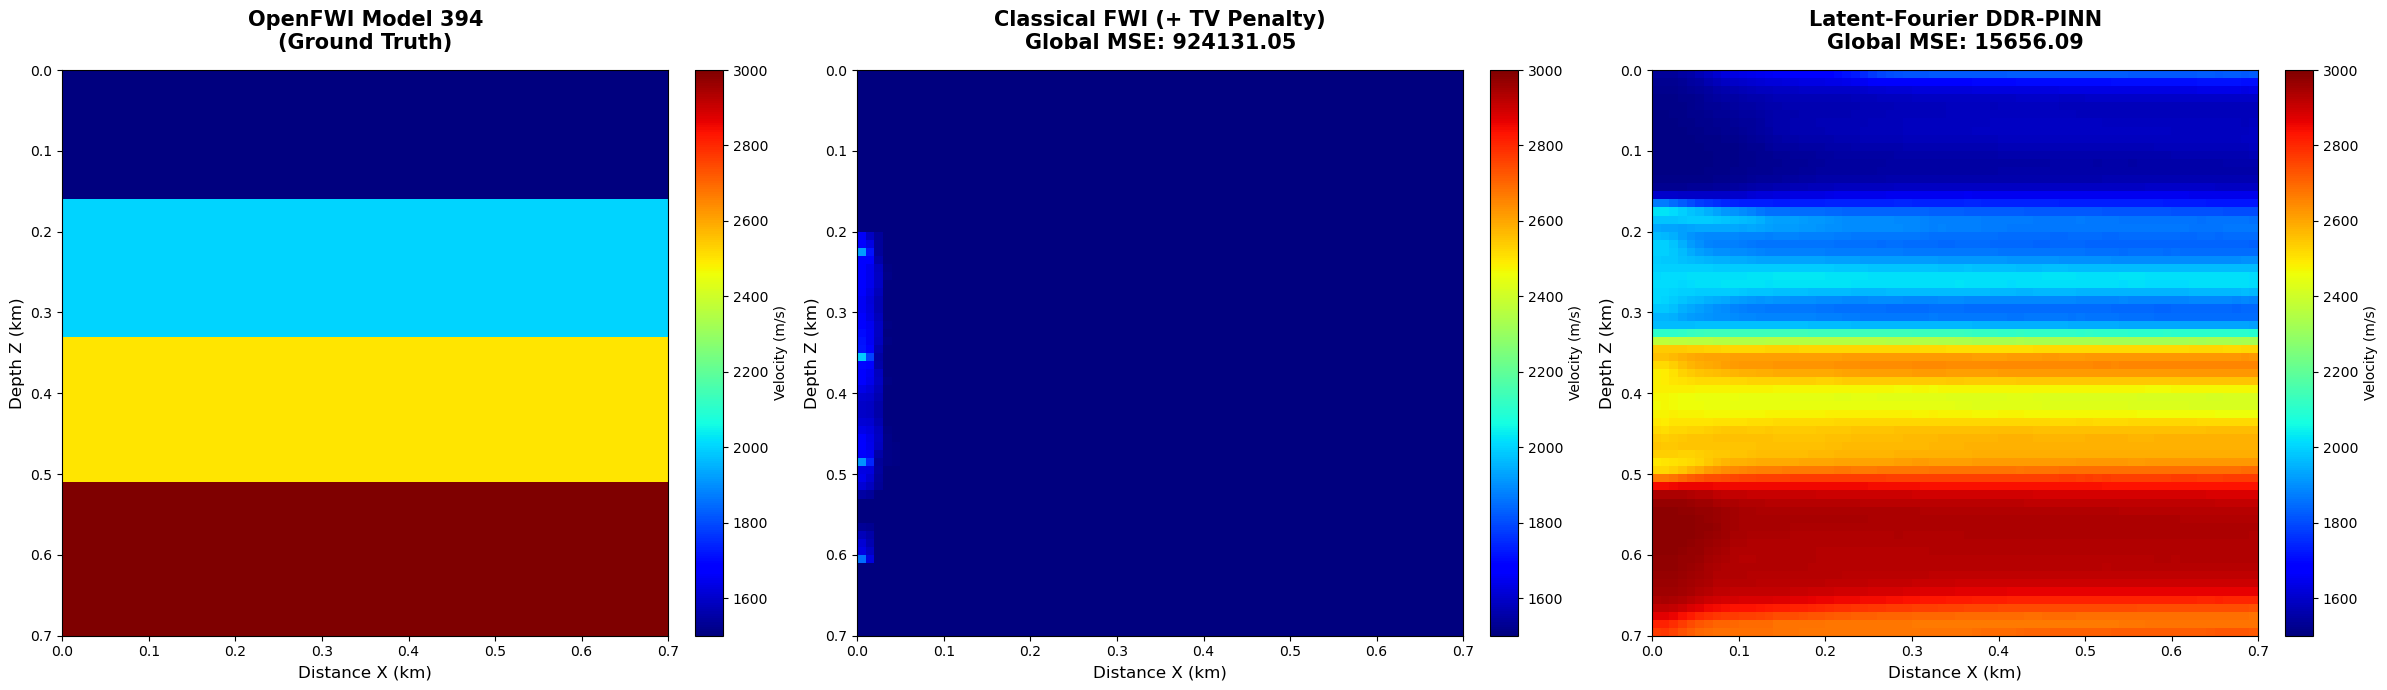

1x3 Ablation Dashboard successfully exported to: C:\Users\limac\Documents\GitHub\ON\piml-pub\proj-01\figures\openfwi_394_ablation_ddrpinn.png


In [15]:
# ==========================================
# CELL-4: FINAL ABLATION DASHBOARD (REGULARIZED FWI vs LATENT-FOURIER DDR-PINN)
# ==========================================
import os
import torch
import matplotlib.pyplot as plt
from skimage.metrics import mean_squared_error as mse

print("Generating OpenFWI 1x3 Ablation Dashboard...")

# 1. Prepare Ground Truth array
true_model_numpy = v_true.cpu().numpy().T

# 2. Extract Latent-Fourier DDR-PINN Model to CPU NumPy
with torch.no_grad():
    v_pred_flat = v_net(x_flat, z_flat)
    pinn_model = v_pred_flat.reshape(nx, ny).cpu().numpy().T

# 3. Calculate Global MSE metrics
mse_fwi = mse(true_model_numpy, classical_fwi_model)
mse_ddr = mse(true_model_numpy, pinn_model)

# 4. Establish physical spatial extents
x_max = (nx * dx) / 1000.0
z_max = (ny * dx) / 1000.0

fig, axes = plt.subplots(1, 3, figsize=(24, 7), facecolor='white')

# --- PANEL 1: Ground Truth ---
im1 = axes[0].imshow(true_model_numpy, aspect='auto', cmap='jet', 
                     extent=[0, x_max, z_max, 0], vmin=1500, vmax=3000)
axes[0].set_title('OpenFWI Model 394\n(Ground Truth)', fontsize=15, fontweight='bold', pad=15)
axes[0].set_xlabel('Distance X (km)', fontsize=12)
axes[0].set_ylabel('Depth Z (km)', fontsize=12)
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, label='Velocity (m/s)')

# --- PANEL 2: Regularized Classical FWI (5 Shots) ---
im2 = axes[1].imshow(classical_fwi_model, aspect='auto', cmap='jet', 
                     extent=[0, x_max, z_max, 0], vmin=1500, vmax=3000)
# TITULAR UPGRADE: Explicitly stating the TV penalty ensures a "fair fight" visual
axes[1].set_title(f'Classical FWI (+ TV Penalty)\nGlobal MSE: {mse_fwi:.2f}', fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel('Distance X (km)', fontsize=12)
axes[1].set_ylabel('Depth Z (km)', fontsize=12)
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label='Velocity (m/s)')

# --- PANEL 3: Latent-Fourier DDR-PINN (5 Shots) ---
im3 = axes[2].imshow(pinn_model, aspect='auto', cmap='jet', 
                     extent=[0, x_max, z_max, 0], vmin=1500, vmax=3000)
axes[2].set_title(f'Latent-Fourier DDR-PINN\nGlobal MSE: {mse_ddr:.2f}', fontsize=15, fontweight='bold', pad=15)
axes[2].set_xlabel('Distance X (km)', fontsize=12)
axes[2].set_ylabel('Depth Z (km)', fontsize=12)
fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04, label='Velocity (m/s)')

plt.tight_layout()

# Export Logic
output_file = os.path.join(FIGURES_DIR, "openfwi_394_ablation_ddrpinn.png")
fig.savefig(output_file, dpi=300, bbox_inches='tight')

plt.show()

print(f"1x3 Ablation Dashboard successfully exported to: {output_file}")